### Import libraries

In [1]:
import pandas
import numpy
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sklearn.model_selection
import sklearn.linear_model
import sklearn.metrics
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent


### Read cleaned datasets

In [2]:
figure3_path = PROJECT_ROOT / "dataset" / "cleaned" / "Figure3_cleaned.csv"
df_neonate = pandas.read_csv(figure3_path)
print("Information about the dataset Figure 3:")
display(df_neonate.head())
print("Shape:", df_neonate.shape)
df_neonate.info()
display(df_neonate.describe().T)
display(df_neonate.isna().sum())
print("Duplicated rows:", df_neonate.duplicated().sum())

Information about the dataset Figure 3:


,pair_id,population,subject_id,session_id,session_day,flow_rate_ul_min,blood_glucose_mmol_l,blood_glucose_mg_dl,skin_glucose_umol_l,skin_glucose_sd_umol_l,sample_collection_period,blood_measurement_time,source_file,source_panel,source_row
0,N001,neonate,NaN,NaN,NaN,0.5,6.7,120.72194,15.0,1.4,NaN,NaN,Figure3.csv,Figure3C,3
1,N002,neonate,NaN,NaN,NaN,0.5,4.9,88.28918,14.2,0.2,NaN,NaN,Figure3.csv,Figure3C,4
2,N003,neonate,NaN,NaN,NaN,0.5,9.8,176.57836,22.0,1.4,NaN,NaN,Figure3.csv,Figure3C,5
3,N004,neonate,NaN,NaN,NaN,0.5,3.9,70.27098,7.8,3.3,NaN,NaN,Figure3.csv,Figure3C,6
4,N005,neonate,NaN,NaN,NaN,0.5,4.6,82.88372,11.1,0.4,NaN,NaN,Figure3.csv,Figure3C,7


Shape: (17, 15)
<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pair_id                   17 non-null     str    
 1   population                17 non-null     str    
 2   subject_id                0 non-null      float64
 3   session_id                0 non-null      float64
 4   session_day               0 non-null      float64
 5   flow_rate_ul_min          17 non-null     float64
 6   blood_glucose_mmol_l      17 non-null     float64
 7   blood_glucose_mg_dl       17 non-null     float64
 8   skin_glucose_umol_l       17 non-null     float64
 9   skin_glucose_sd_umol_l    17 non-null     float64
 10  sample_collection_period  0 non-null      float64
 11  blood_measurement_time    0 non-null      float64
 12  source_file               17 non-null     str    
 13  source_panel              17 non-null     str    
 14  source_

,count,mean,std,min,25%,50%,75%,max
subject_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
session_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
session_day,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flow_rate_ul_min,17.0,0.500000,0.000000,0.5000,0.50000,0.50000,0.50000,0.50000
blood_glucose_mmol_l,17.0,5.823529,2.324470,3.5000,4.40000,4.90000,6.70000,11.40000
blood_glucose_mg_dl,17.0,104.929518,41.882769,63.0637,79.28008,88.28918,120.72194,205.40748
skin_glucose_umol_l,17.0,13.097059,5.387673,7.2000,9.40000,11.70000,15.00000,27.00000
skin_glucose_sd_umol_l,17.0,1.776471,1.061561,0.2000,0.80000,1.70000,2.50000,3.30000
sample_collection_period,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
blood_measurement_time,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


pair_id                      0
population                   0
subject_id                  17
session_id                  17
session_day                 17
flow_rate_ul_min             0
blood_glucose_mmol_l         0
blood_glucose_mg_dl          0
skin_glucose_umol_l          0
skin_glucose_sd_umol_l       0
sample_collection_period    17
blood_measurement_time      17
source_file                  0
source_panel                 0
source_row                   0
dtype: int64

Duplicated rows: 0


In [3]:
figure4_path = PROJECT_ROOT / "dataset" / "cleaned" / "Figure4_cleaned.csv"
df_adult = pandas.read_csv(figure4_path)
print("Information about the dataset Figure 4:")
display(df_adult.head())
print("Shape:", df_adult.shape)
df_adult.info()
display(df_adult.describe().T)
display(df_adult.isna().sum())
print("Duplicated rows:", df_adult.duplicated().sum())

Information about the dataset Figure 4:


,pair_id,population,subject_id,session_id,session_day,flow_rate_ul_min,blood_glucose_mmol_l,blood_glucose_mg_dl,skin_glucose_umol_l,skin_glucose_sd_umol_l,sample_collection_period,blood_measurement_time,source_file,source_panel,source_row
0,A001,adult,adult_1,day_0,0.0,0.5,4.3,77.47826,12.5,0.8,11:20 - 11:40,11:28:00,Figure4.csv,Figure4,4
1,A002,adult,adult_1,day_0,0.0,0.5,4.1,73.87462,9.1,0.4,11:40 - 12:01,11:48:00,Figure4.csv,Figure4,5
2,A003,adult,adult_1,day_0,0.0,0.5,4.7,84.68554,16.1,0.9,12:01 - 12:21,12:09:00,Figure4.csv,Figure4,6
3,A004,adult,adult_1,day_0,0.0,0.5,4.2,75.67644,11.9,0.5,12:21 - 12:42,12:29:00,Figure4.csv,Figure4,7
4,A005,adult,adult_1,day_0,0.0,0.5,4.4,79.28008,13.5,0.3,12:42 - 13:03,12:51:00,Figure4.csv,Figure4,8


Shape: (54, 15)
<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pair_id                   54 non-null     str    
 1   population                54 non-null     str    
 2   subject_id                54 non-null     str    
 3   session_id                54 non-null     str    
 4   session_day               20 non-null     float64
 5   flow_rate_ul_min          54 non-null     float64
 6   blood_glucose_mmol_l      54 non-null     float64
 7   blood_glucose_mg_dl       54 non-null     float64
 8   skin_glucose_umol_l       54 non-null     float64
 9   skin_glucose_sd_umol_l    54 non-null     float64
 10  sample_collection_period  54 non-null     str    
 11  blood_measurement_time    54 non-null     str    
 12  source_file               54 non-null     str    
 13  source_panel              54 non-null     str    
 14  source_

,count,mean,std,min,25%,50%,75%,max
session_day,20.0,25.250000,23.501120,0.00000,9.00000,20.0000,36.250000,61.00000
flow_rate_ul_min,54.0,0.500000,0.000000,0.50000,0.50000,0.5000,0.500000,0.50000
blood_glucose_mmol_l,54.0,5.922840,1.578071,4.10000,4.70000,5.5000,6.675000,10.80000
blood_glucose_mg_dl,54.0,106.718907,28.433993,73.87462,84.68554,99.1001,120.271485,194.59656
skin_glucose_umol_l,54.0,11.150000,4.924094,2.20000,6.70000,10.9000,14.900000,25.10000
skin_glucose_sd_umol_l,54.0,0.924074,0.637192,0.20000,0.50000,0.7000,1.200000,2.80000
source_row,54.0,44.888889,24.655870,4.00000,23.25000,45.5000,67.000000,84.00000


pair_id                      0
population                   0
subject_id                   0
session_id                   0
session_day                 34
flow_rate_ul_min             0
blood_glucose_mmol_l         0
blood_glucose_mg_dl          0
skin_glucose_umol_l          0
skin_glucose_sd_umol_l       0
sample_collection_period     0
blood_measurement_time       0
source_file                  0
source_panel                 0
source_row                   0
dtype: int64

Duplicated rows: 0


### Select the baseline variables

Only inspect the non-invasive input (`skin_glucose_umol_l`) and the reference target (`blood_glucose_mmol_l`) at this stage. Metadata and the converted target in mg/dL are not model features.

In [4]:
MODEL_COLUMNS = ["skin_glucose_umol_l", "blood_glucose_mmol_l"]

neonate_values = df_neonate[MODEL_COLUMNS].copy()
adult_values = df_adult[MODEL_COLUMNS].copy()

print("Neonate model variables:")
display(neonate_values.describe().T)

print("Adult model variables:")
display(adult_values.describe().T)

Neonate model variables:


,count,mean,std,min,25%,50%,75%,max
skin_glucose_umol_l,17.0,13.097059,5.387673,7.2,9.4,11.7,15.0,27.0
blood_glucose_mmol_l,17.0,5.823529,2.324470,3.5,4.4,4.9,6.7,11.4


Adult model variables:


,count,mean,std,min,25%,50%,75%,max
skin_glucose_umol_l,54.0,11.15000,4.924094,2.2,6.7,10.9,14.900,25.1
blood_glucose_mmol_l,54.0,5.92284,1.578071,4.1,4.7,5.5,6.675,10.8


### Check correlation and adult group structure

Correlation is exploratory only; it does not replace validation. Adult counts are shown by subject and session because later train/test splitting must preserve these groups.

In [5]:
neonate_correlation = neonate_values.corr().loc["skin_glucose_umol_l", "blood_glucose_mmol_l"]
adult_correlation = adult_values.corr().loc["skin_glucose_umol_l", "blood_glucose_mmol_l"]

print(f"Neonate Pearson correlation: {neonate_correlation:.4f}")
print(f"Adult pooled Pearson correlation: {adult_correlation:.4f}")

adult_group_counts = (
    df_adult.groupby(["subject_id", "session_id"], dropna=False)
    .size()
    .rename("n_samples")
    .reset_index()
)
display(adult_group_counts)

Neonate Pearson correlation: 0.9585
Adult pooled Pearson correlation: -0.1229


,subject_id,session_id,n_samples
0,adult_1,day_0,5
1,adult_1,day_12,5
2,adult_1,day_28,5
3,adult_1,day_61,5
4,adult_2,single_session,5
5,adult_3,single_session,5
6,adult_4,single_session,5
7,adult_5,single_session,5
8,adult_6,single_session,7
9,adult_7,single_session,7


### Visualize skin glucose versus blood glucose

The adult plot uses one color per subject so that a weak pooled relationship is not confused with the within-subject trends.

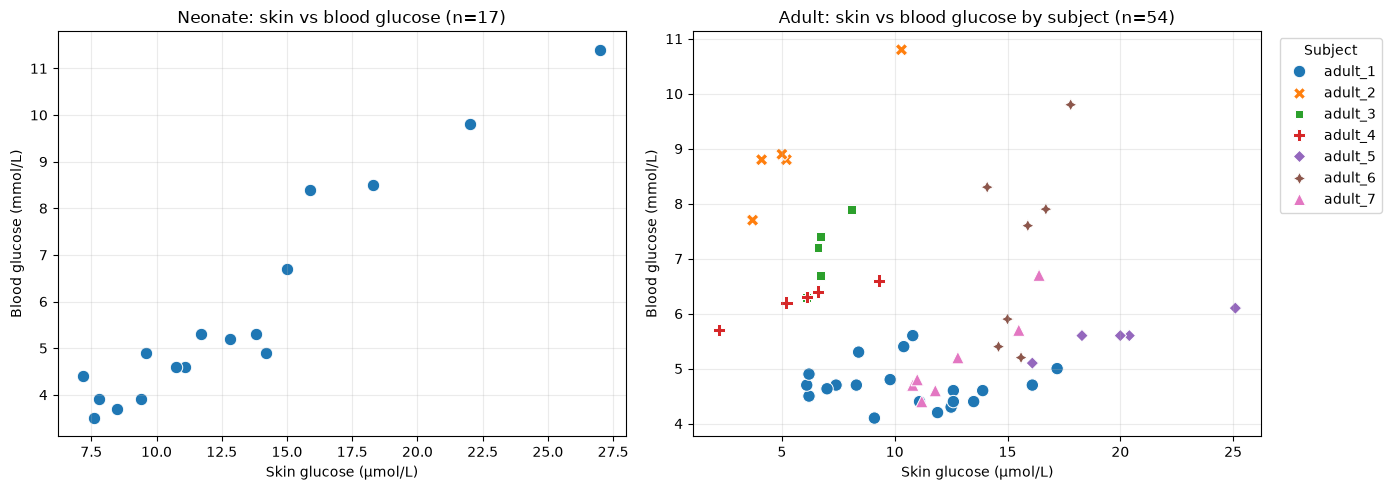

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df_neonate,
    x="skin_glucose_umol_l",
    y="blood_glucose_mmol_l",
    s=80,
    ax=axes[0],
)
axes[0].set_title("Neonate: skin vs blood glucose (n=17)")
axes[0].set_xlabel("Skin glucose (µmol/L)")
axes[0].set_ylabel("Blood glucose (mmol/L)")
axes[0].grid(alpha=0.25)

sns.scatterplot(
    data=df_adult,
    x="skin_glucose_umol_l",
    y="blood_glucose_mmol_l",
    hue="subject_id",
    style="subject_id",
    s=80,
    ax=axes[1],
)
axes[1].set_title("Adult: skin vs blood glucose by subject (n=54)")
axes[1].set_xlabel("Skin glucose (µmol/L)")
axes[1].set_ylabel("Blood glucose (mmol/L)")
axes[1].grid(alpha=0.25)
axes[1].legend(title="Subject", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Reproduce the paper's Figure 3 regression

In [7]:
X_paper = df_neonate[["blood_glucose_mmol_l"]]
y_paper = df_neonate["skin_glucose_umol_l"]

paper_ols = sklearn.linear_model.LinearRegression()
paper_ols.fit(X_paper, y_paper)

predicted_skin = paper_ols.predict(X_paper)

print("Slope:", paper_ols.coef_[0])
print("Intercept:", paper_ols.intercept_)
print(
    "R2:",
    sklearn.metrics.r2_score(y_paper, predicted_skin),
)

Slope: 2.2215138195228827
Intercept: 0.1600077568961531
R2: 0.9186361369598148


In [8]:
skin_sd = df_neonate["skin_glucose_sd_umol_l"]
weights = 1 / numpy.square(skin_sd)

paper_wls = sklearn.linear_model.LinearRegression()
paper_wls.fit(
    X_paper,
    y_paper,
    sample_weight=weights,
)

predicted_skin_wls = paper_wls.predict(X_paper)

print("Weighted slope:", paper_wls.coef_[0])
print("Weighted intercept:", paper_wls.intercept_)
print(
    "Weighted R2:",
    sklearn.metrics.r2_score(
        y_paper,
        predicted_skin_wls,
        sample_weight=weights,
    ),
)

Weighted slope: 2.015750908296843
Weighted intercept: 2.8406627496148094
Weighted R2: 0.523714150378602


/home/nhmquoc/Secure-IoMT-Embedded-Platform/quoc_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/nhmquoc/Secure-IoMT-Embedded-Platform/quoc_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


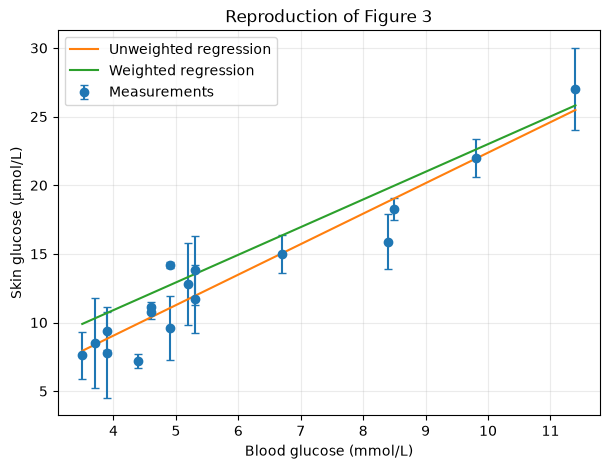

In [9]:
blood_grid = numpy.linspace(
    X_paper.iloc[:, 0].min(),
    X_paper.iloc[:, 0].max(),
    100,
).reshape(-1, 1)

plt.figure(figsize=(7, 5))

plt.errorbar(
    df_neonate["blood_glucose_mmol_l"],
    df_neonate["skin_glucose_umol_l"],
    yerr=df_neonate["skin_glucose_sd_umol_l"],
    fmt="o",
    capsize=3,
    label="Measurements",
)

plt.plot(
    blood_grid,
    paper_ols.predict(blood_grid),
    label="Unweighted regression",
)

plt.plot(
    blood_grid,
    paper_wls.predict(blood_grid),
    label="Weighted regression",
)

plt.xlabel("Blood glucose (mmol/L)")
plt.ylabel("Skin glucose (µmol/L)")
plt.title("Reproduction of Figure 3")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### Neonate prediction: Dummy Mean versus Linear Regression

This section changes to the deployment direction: `skin glucose -> blood glucose`. Both models are evaluated with the same 17-fold Leave-One-Out Cross-Validation (LOOCV). Dummy Mean ignores skin glucose and predicts the mean blood glucose of each training fold; it provides the minimum baseline that Linear Regression should beat.

In [10]:
import sklearn.dummy

X_neonate_ml = df_neonate[["skin_glucose_umol_l"]]
y_neonate_ml = df_neonate["blood_glucose_mmol_l"]
loo = sklearn.model_selection.LeaveOneOut()

baseline_models = {
    "Dummy Mean": sklearn.dummy.DummyRegressor(strategy="mean"),
    "Linear Regression": sklearn.linear_model.LinearRegression(),
}

loocv_predictions = {}
metric_rows = []

for model_name, model in baseline_models.items():
    predictions = sklearn.model_selection.cross_val_predict(
        model,
        X_neonate_ml,
        y_neonate_ml,
        cv=loo,
    )
    loocv_predictions[model_name] = predictions
    metric_rows.append({
        "model": model_name,
        "MAE_mmol_l": sklearn.metrics.mean_absolute_error(y_neonate_ml, predictions),
        "RMSE_mmol_l": numpy.sqrt(
            sklearn.metrics.mean_squared_error(y_neonate_ml, predictions)
        ),
        "R2": sklearn.metrics.r2_score(y_neonate_ml, predictions),
    })

loocv_metrics = pandas.DataFrame(metric_rows)
print(f"Samples: {len(X_neonate_ml)}; LOOCV folds: {loo.get_n_splits(X_neonate_ml)}")
display(loocv_metrics.round(3))

Samples: 17; LOOCV folds: 17


,model,MAE_mmol_l,RMSE_mmol_l,R2
0,Dummy Mean,1.96,2.396,-0.129
1,Linear Regression,0.55,0.706,0.902


### Inspect predictions and errors

The table identifies the most difficult samples. In the plots, a useful model should place points closer to the dashed perfect-prediction line than Dummy Mean does.

,pair_id,skin_glucose_umol_l,actual_blood_mmol_l,dummy_prediction_mmol_l,linear_prediction_mmol_l,linear_error_mmol_l,linear_absolute_error_mmol_l
10,N011,15.90,8.4,5.662,6.866,-1.534,1.534
1,N002,14.20,4.9,5.881,6.370,1.470,1.470
12,N013,7.20,4.4,5.913,3.228,-1.172,1.172
9,N010,13.80,5.3,5.856,6.166,0.866,0.866
6,N007,18.30,8.5,5.656,7.905,-0.595,0.595
11,N012,9.60,4.9,5.881,4.329,-0.571,0.571
8,N009,12.80,5.2,5.862,5.732,0.532,0.532
16,N017,9.40,3.9,5.944,4.333,0.433,0.433
4,N005,11.10,4.6,5.900,5.026,0.426,0.426
2,N003,22.00,9.8,5.575,9.417,-0.383,0.383


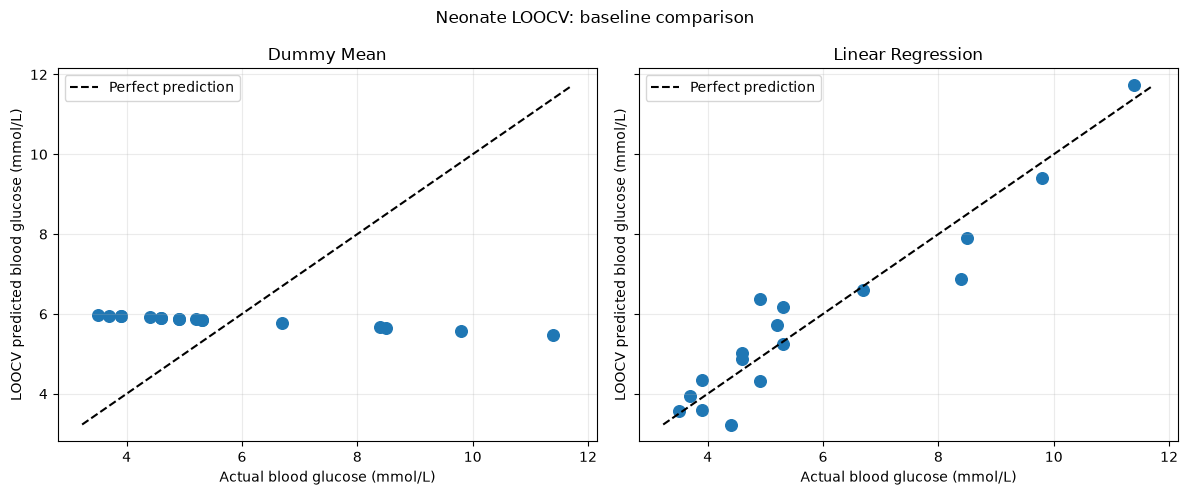

In [ ]:
neonate_cv_results = pandas.DataFrame({
    "pair_id": df_neonate["pair_id"],
    "skin_glucose_umol_l": X_neonate_ml["skin_glucose_umol_l"],
    "actual_blood_mmol_l": y_neonate_ml,
    "dummy_prediction_mmol_l": loocv_predictions["Dummy Mean"],
    "linear_prediction_mmol_l": loocv_predictions["Linear Regression"],
})
neonate_cv_results["linear_error_mmol_l"] = (
    neonate_cv_results["linear_prediction_mmol_l"]
    - neonate_cv_results["actual_blood_mmol_l"]
)
neonate_cv_results["linear_absolute_error_mmol_l"] = (
    neonate_cv_results["linear_error_mmol_l"].abs()
)

display(
    neonate_cv_results.sort_values(
        "linear_absolute_error_mmol_l", ascending=False
    ).round(3)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
plot_min = min(
    y_neonate_ml.min(),
    min(prediction.min() for prediction in loocv_predictions.values()),
)
plot_max = max(
    y_neonate_ml.max(),
    max(prediction.max() for prediction in loocv_predictions.values()),
)

for ax, (model_name, predictions) in zip(axes, loocv_predictions.items()):
    ax.scatter(y_neonate_ml, predictions, s=70)
    ax.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        linestyle="--",
        color="black",
        label="Perfect prediction",
    )
    ax.set_title(model_name)
    ax.set_xlabel("Actual blood glucose (mmol/L)")
    ax.set_ylabel("LOOCV predicted blood glucose (mmol/L)")
    ax.grid(alpha=0.25)
    ax.legend()

fig.suptitle("Neonate LOOCV: baseline comparison")
plt.tight_layout()
plt.show()



### Fit the final Figure 3 model

After evaluating the method with LOOCV, fit one final Linear Regression on all 17 samples. This model is for deployment; its performance must still be reported using the LOOCV metrics above, not predictions on its training data.

In [12]:
final_neonate_model = sklearn.linear_model.LinearRegression()
final_neonate_model.fit(X_neonate_ml, y_neonate_ml)

neonate_slope = float(final_neonate_model.coef_[0])
neonate_intercept = float(final_neonate_model.intercept_)

print(f"Final slope: {neonate_slope:.9f} mmol/L per µmol/L")
print(f"Final intercept: {neonate_intercept:.9f} mmol/L")
print(
    "Deployment equation: "
    f"blood_glucose = {neonate_slope:.9f} * skin_glucose + "
    f"{neonate_intercept:.9f}"
)

example_skin_glucose = 15.0
example_blood_glucose = (
    neonate_slope * example_skin_glucose + neonate_intercept
)
print(
    f"Example: skin={example_skin_glucose:.1f} µmol/L -> "
    f"blood={example_blood_glucose:.3f} mmol/L"
)

Final slope: 0.413518083 mmol/L per µmol/L
Final intercept: 0.407658749 mmol/L
Deployment equation: blood_glucose = 0.413518083 * skin_glucose + 0.407658749
Example: skin=15.0 µmol/L -> blood=6.610 mmol/L
